# 02 – Clustering

**Bachelorarbeit – Mohamed Mohamady · Universität Paderborn · 2026**
*K-Means-Clustering und alle Cluster-Abbildungen. Tabelle 6.*

Ausgaben werden in `03_Output/final_run/` gespeichert. Wiederkehrende Bausteine
(Cluster-Definition, Farben, Tabellen-Renderer) liegen in `utils.py`.


## 1. Bibliotheken und Pfade

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# Shared cluster definition, colours and table helper (see utils.py)
sys.path.insert(0, r"C:\Users\LEGION\Desktop\Bachelorarbeit\02_Code\final_notebooks")
from utils import make_clusters, save_table, GREEN, ORANGE, CLUSTER_VARS

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 11

# Cleaned panel from notebook 01, plus this run's output folder.
CLEAN_DATA = Path(r"C:\Users\LEGION\Desktop\Bachelorarbeit\03_Output\final_run\master_panel_clean.xlsx")
OUTPUT_DIR = Path(r"C:\Users\LEGION\Desktop\Bachelorarbeit\03_Output\final_run")

# One axis label per clustering variable for the radar chart.
radar_labels = ["Internet\nAccess", "Internet\nUse", "Cloud", "Fixed\nBB",
                "Secure\nServers", "HighTech\nExp", "R&D"]

## 2. Daten laden und Cluster bilden

In [2]:
panel = pd.read_excel(CLEAN_DATA).sort_values(["Country", "Year"]).reset_index(drop=True)

# k=2 K-Means on standardised country averages, labelled by average GDP.
panel, country_means, advanced, NAMES, COLORS = make_clusters(panel)
cluster_profile = country_means.groupby("Cluster")[CLUSTER_VARS].mean()

for cluster in [advanced, 1 - advanced]:
    members = sorted(country_means[country_means.Cluster == cluster].index.tolist())
    subset = panel[panel.Cluster == cluster]
    print(f"{NAMES[cluster]} (N={len(members)}): "
          f"Ø-GDP {subset['GDP Per Capita PPS'].mean():,.0f} | "
          f"Ø-Internetnutzung {subset['Internet Use'].mean():.1f}% | "
          f"Ø-F&E {subset['R&D expenditure'].mean():,.0f}")
    print("  " + ", ".join(members))

Advanced Digital Economies (N=14): Ø-GDP 43,004 | Ø-Internetnutzung 92.7% | Ø-F&E 1,039
  Austria, Belgium, Cyprus, Czechia, Denmark, Estonia, Finland, France, Germany, Ireland, Luxembourg, Malta, Netherlands, Sweden
Catching-up Economies (N=13): Ø-GDP 25,796 | Ø-Internetnutzung 82.7% | Ø-F&E 252
  Bulgaria, Croatia, Greece, Hungary, Italy, Latvia, Lithuania, Poland, Portugal, Romania, Slovakia, Slovenia, Spain


## 3. Elbow-Methode und Silhouette-Score

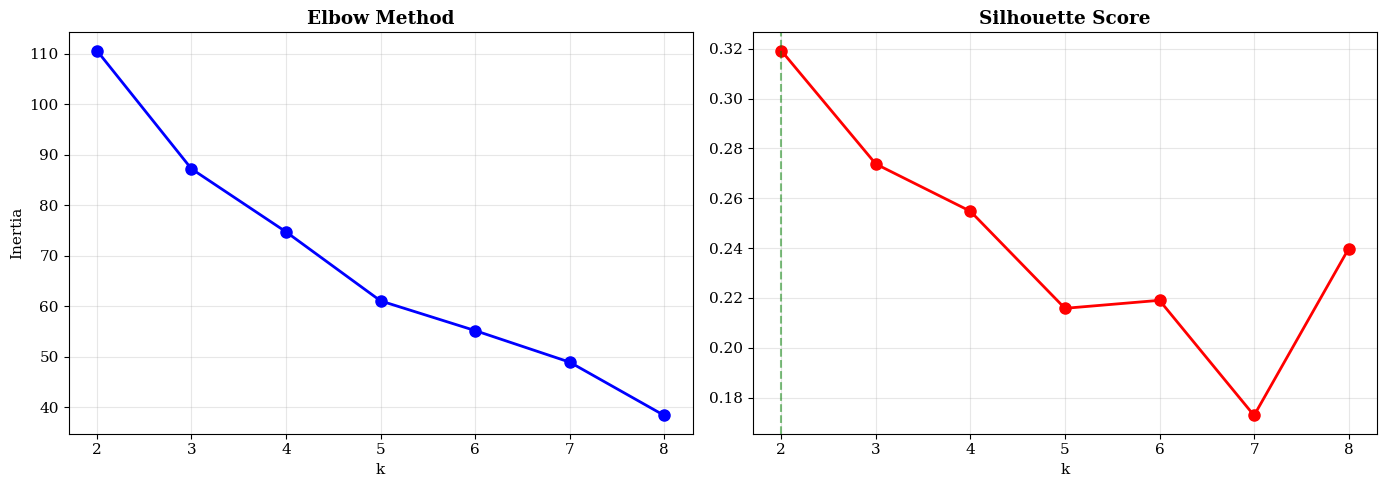

In [3]:
standardised = StandardScaler().fit_transform(panel.groupby("Country")[CLUSTER_VARS].mean())
k_values = range(2, 9)
inertia = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(standardised).inertia_ for k in k_values]
silhouette = [silhouette_score(standardised, KMeans(n_clusters=k, random_state=42, n_init=10).fit(standardised).labels_)
              for k in k_values]

fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5))
left.plot(list(k_values), inertia, "bo-", lw=2, ms=8)
left.set_title("Elbow Method", fontweight="bold"); left.set_xlabel("k"); left.set_ylabel("Inertia"); left.grid(alpha=0.3)
right.plot(list(k_values), silhouette, "ro-", lw=2, ms=8)
right.axvline(2, color="green", ls="--", alpha=0.5)
right.set_title("Silhouette Score", fontweight="bold"); right.set_xlabel("k"); right.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "elbow_silhouette.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Europakarte mit Cluster-Farben

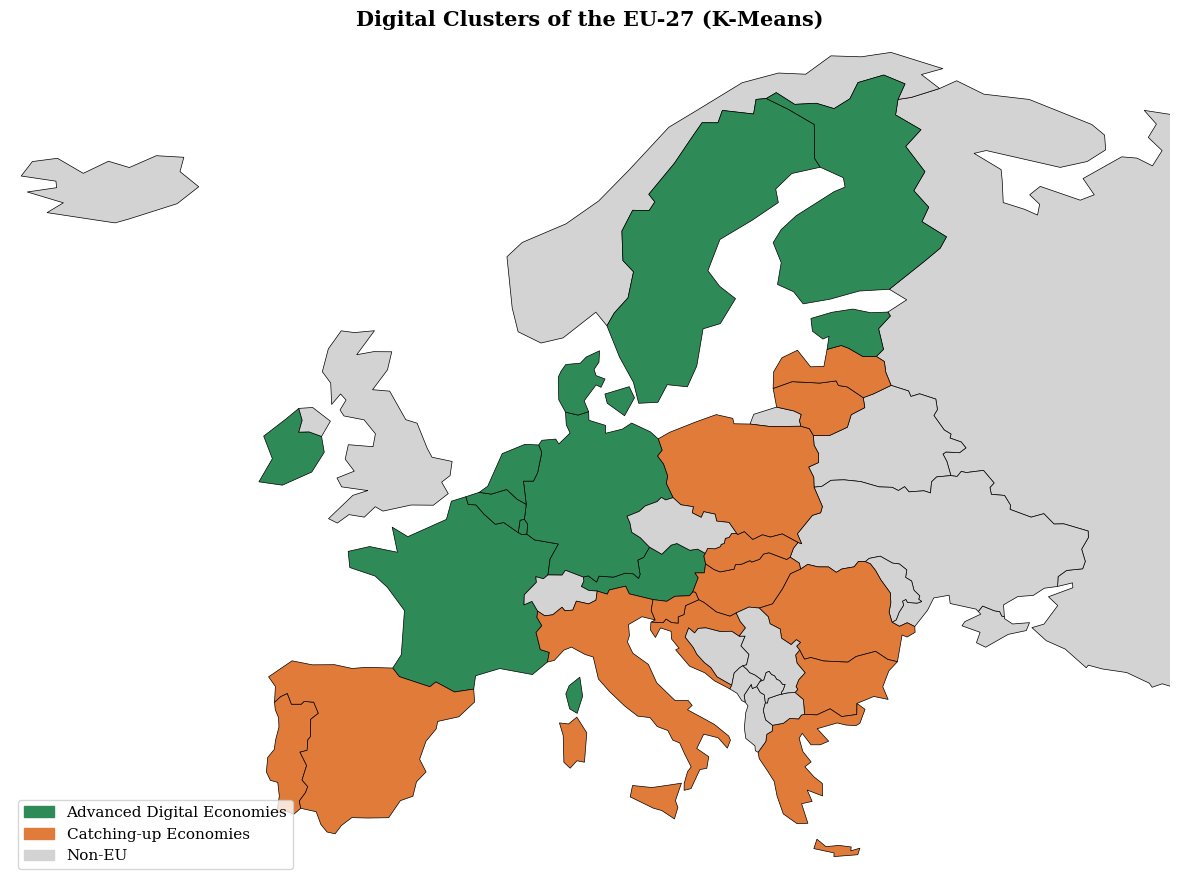

In [4]:
# Choropleth of the EU-27 coloured by cluster (Natural Earth boundaries).
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
cluster_lookup = country_means[["Cluster"]].reset_index()
cluster_lookup.columns = ["Country", "Cluster"]
cluster_lookup["Country_map"] = cluster_lookup["Country"].replace({"Czechia": "Czech Republic"})

europe = world[world["CONTINENT"] == "Europe"].merge(
    cluster_lookup, left_on="NAME", right_on="Country_map", how="left")
europe["color"] = europe["Cluster"].map(COLORS).fillna("#D3D3D3")

fig, ax = plt.subplots(figsize=(13, 9))
europe.plot(color=europe["color"], edgecolor="black", linewidth=0.5, ax=ax)
ax.set_xlim(-25, 45); ax.set_ylim(34, 72); ax.axis("off")
ax.set_title("Digital Clusters of the EU-27 (K-Means)", fontsize=15, fontweight="bold")
ax.legend(handles=[mpatches.Patch(color=COLORS[advanced], label=NAMES[advanced]),
                   mpatches.Patch(color=COLORS[1 - advanced], label=NAMES[1 - advanced]),
                   mpatches.Patch(color="#D3D3D3", label="Non-EU")],
          loc="lower left", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_map_europe.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Radar-Diagramm (Min-Max über alle 27 Länder)

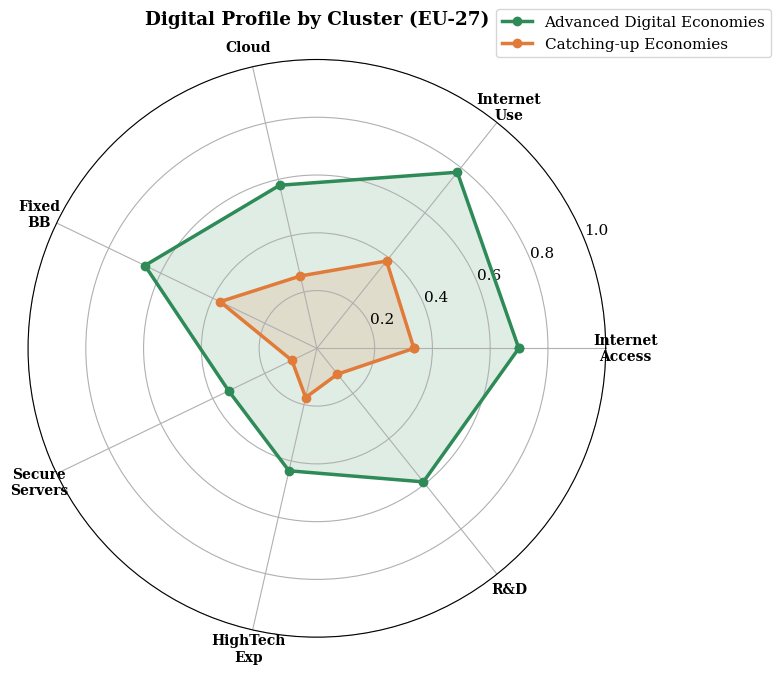

Catching-up (normalisiert, muss > 0 sein):
Internet Access     0.336
Internet Use        0.387
Cloud Computing     0.257
Fixed_Broadband     0.372
Secure_Servers      0.096
HighTech_Exports    0.175
R&D expenditure     0.114


In [5]:
# Normalise each variable Min-Max across the 27 countries, then average per cluster.
# Normalising across all countries (not just the two cluster means) keeps the
# Catching-up profile visibly above zero.
country_only = panel.groupby("Country")[CLUSTER_VARS].mean()
normalised = (country_only - country_only.min()) / (country_only.max() - country_only.min())
radar_profile = normalised.assign(Cluster=country_means["Cluster"]).groupby("Cluster")[CLUSTER_VARS].mean()

angles = [n / 7.0 * 2 * np.pi for n in range(7)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for cluster in [advanced, 1 - advanced]:
    values = radar_profile.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", lw=2.5, color=COLORS[cluster], label=NAMES[cluster])
    ax.fill(angles, values, alpha=0.15, color=COLORS[cluster])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10, fontweight="bold")
ax.set_ylim(0, 1)
ax.set_title("Digital Profile by Cluster (EU-27)", fontweight="bold", pad=25)
ax.legend(bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_radar.png", dpi=300, bbox_inches="tight")
plt.show()

print("Catching-up (normalisiert, muss > 0 sein):")
print(radar_profile.loc[1 - advanced].round(3).to_string())

## 6. Heatmap der Cluster-Profile

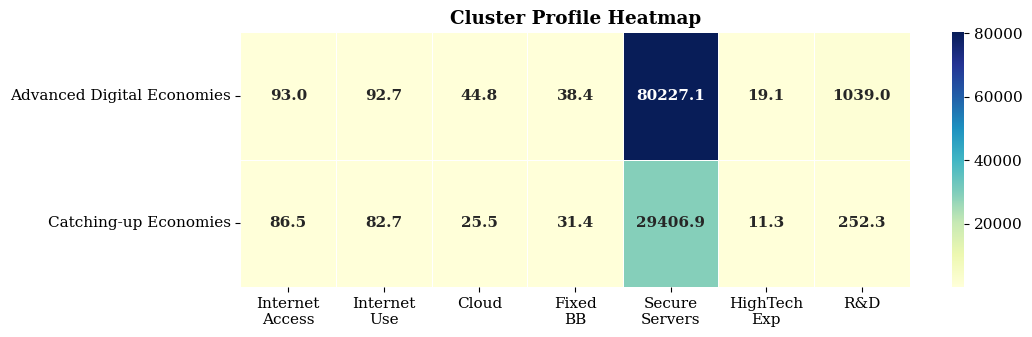

In [6]:
heatmap_data = cluster_profile.copy()
heatmap_data.index = [NAMES[i] for i in heatmap_data.index]
heatmap_data.columns = radar_labels
fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5, ax=ax,
            annot_kws={"fontweight": "bold"})
ax.set_title("Cluster Profile Heatmap", fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. GDP-Balken nach Cluster

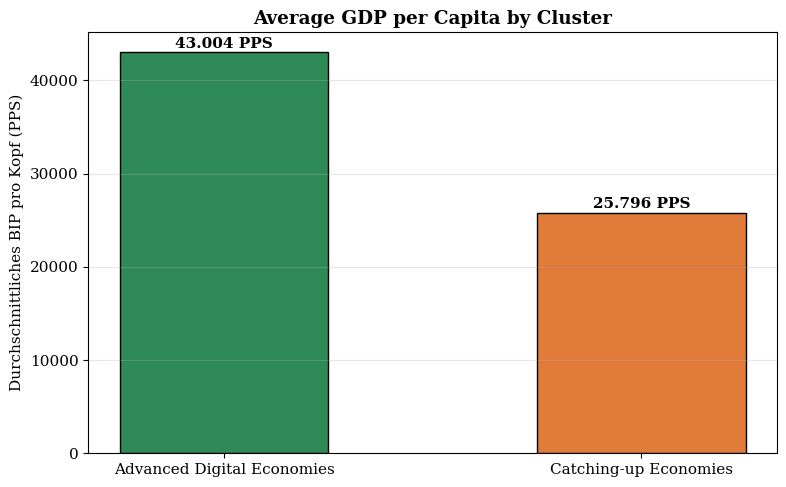

In [7]:
mean_gdp = panel.groupby("Cluster")["GDP Per Capita PPS"].mean()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([NAMES[i] for i in mean_gdp.index], mean_gdp.values,
              color=[COLORS[i] for i in mean_gdp.index], edgecolor="black", width=0.5)
for bar, value in zip(bars, mean_gdp.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f"{value:,.0f} PPS".replace(",", "."), ha="center", fontweight="bold")
ax.set_ylabel("Durchschnittliches BIP pro Kopf (PPS)")
ax.set_title("Average GDP per Capita by Cluster", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_gdp_barchart.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Internetnutzungs-Trend nach Cluster

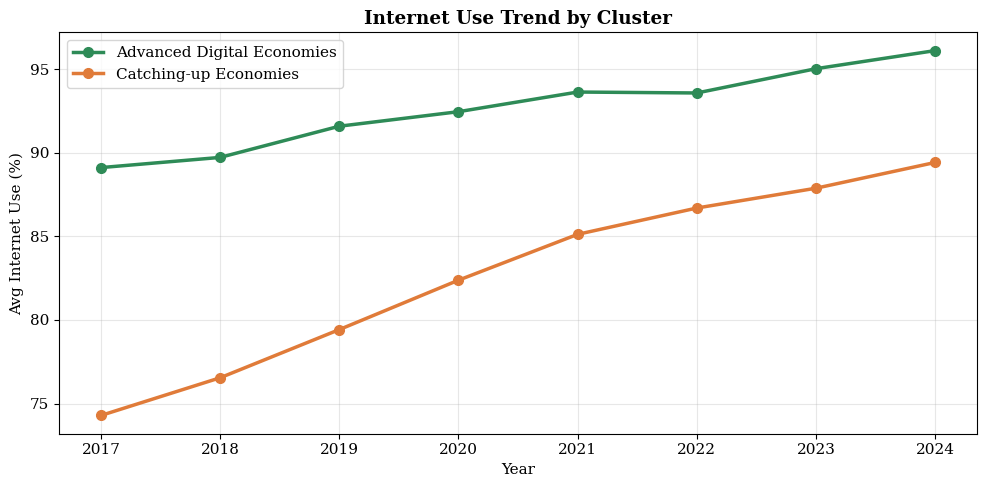

In [8]:
usage_trend = panel.groupby(["Year", "Cluster"])["Internet Use"].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
for cluster in [advanced, 1 - advanced]:
    series = usage_trend[usage_trend["Cluster"] == cluster]
    ax.plot(series["Year"], series["Internet Use"], "o-", lw=2.5,
            color=COLORS[cluster], label=NAMES[cluster], ms=7)
ax.set_xlabel("Year")
ax.set_ylabel("Avg Internet Use (%)")
ax.set_title("Internet Use Trend by Cluster", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_trend_internetuse.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Tabelle 6 – Cluster-Zusammensetzung

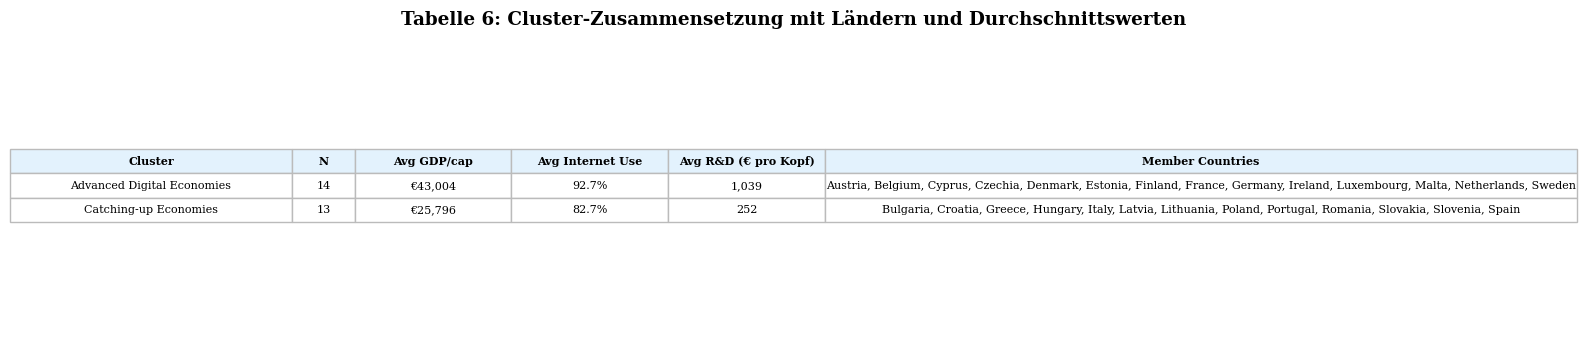

In [9]:
composition = []
for cluster in [advanced, 1 - advanced]:
    subset = panel[panel.Cluster == cluster]
    members = sorted(country_means[country_means.Cluster == cluster].index.tolist())
    composition.append([NAMES[cluster], str(len(members)),
                        f"€{subset['GDP Per Capita PPS'].mean():,.0f}",
                        f"{subset['Internet Use'].mean():.1f}%",
                        f"{subset['R&D expenditure'].mean():,.0f}",
                        ", ".join(members)])
save_table(composition,
           ["Cluster", "N", "Avg GDP/cap", "Avg Internet Use", "Avg R&D (€ pro Kopf)", "Member Countries"],
           OUTPUT_DIR / "table6_cluster_composition.png",
           "Tabelle 6: Cluster-Zusammensetzung mit Ländern und Durchschnittswerten",
           col_widths=[0.18, 0.04, 0.10, 0.10, 0.10, 0.48], fontsize=8, figsize=(16, 3.5))

## 10. Verifikation der Cluster-Kennzahlen

Advanced N=14: True | Ø-GDP 43004: True | Catching Ø-GDP 25796: True
